In [1]:
import torch

print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU Available: True
GPU: Tesla T4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install -q transformers datasets accelerate evaluate librosa soundfile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00


In [4]:
import os
import librosa
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from transformers import (
    Wav2Vec2Processor,
    Wav2Vec2ForSequenceClassification,
    Trainer,
    TrainingArguments
)

In [5]:
df = pd.read_csv('/content/Book 2(Sheet1).csv')

print(df.head())
print(df.shape)
print(df.columns)

    FILE_NAME LANGUAGE  AGE LOCALITY                CONDITION STRESS_LEVEL  \
0  audio1.MP4    HINDI   56    RURAL  After waking from sleep     STRESSED   
1  audio2.MP4    HINDI   56    RURAL                  sitting     STRESSED   
2  audio3.MP4    HINDI   56    RURAL                  sitting   UNSTRESSED   
3  audio4.MP4    HINDI   56    RURAL                  sitting     STRESSED   
4  audio5.MP4    HINDI   56    RURAL                  sitting   UNSTRESSED   

   GENDER MARITAL_STATUS OCCUPATION  SLEEP_HOURS PHYSICAL_ACTIVITY  
0  FEMALE        Married  Homemaker            6              High  
1  FEMALE        Married  Homemaker            6              High  
2  FEMALE        Married  Homemaker            8               Low  
3  FEMALE        Married  Homemaker            7              High  
4  FEMALE        Married  Homemaker            7              High  
(280, 11)
Index(['FILE_NAME', 'LANGUAGE', 'AGE', 'LOCALITY', 'CONDITION', 'STRESS_LEVEL',
       'GENDER', 'MARITAL_S

In [6]:
print(df.columns)

Index(['FILE_NAME', 'LANGUAGE', 'AGE', 'LOCALITY', 'CONDITION', 'STRESS_LEVEL',
       'GENDER', 'MARITAL_STATUS', 'OCCUPATION', 'SLEEP_HOURS',
       'PHYSICAL_ACTIVITY'],
      dtype='object')


In [7]:
audio_folder = "/content/drive/MyDrive/audio_files/audio_files"

In [8]:
import os

audio_folder = "/content/drive/MyDrive/audio_files/audio_files"

print("Total Audio Files:", len(os.listdir(audio_folder)))
print(os.listdir(audio_folder)[:10])

Total Audio Files: 280
['audio1.mp4', 'audio4.mp4', 'audio2.mp4', 'audio3.mp4', 'audio8.mp4', 'audio5.mp4', 'audio6.mp4', 'audio7.mp4', 'audio11.mp4', 'audio9.mp4']


In [9]:
!apt-get install ffmpeg -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.


In [10]:
import os

input_folder = "/content/drive/MyDrive/audio_files/audio_files"
output_folder = "/content/wav_files"

os.makedirs(output_folder, exist_ok=True)

for file in os.listdir(input_folder):

    if file.endswith(".mp4"):

        input_path = os.path.join(input_folder, file)

        output_path = os.path.join(
            output_folder,
            file.replace(".mp4", ".wav")
        )

        os.system(
            f'ffmpeg -i "{input_path}" -ar 16000 -ac 1 "{output_path}" -loglevel quiet'
        )

print("Conversion Completed")

Conversion Completed


In [11]:
import os

print(
    "Total WAV Files:",
    len(os.listdir("/content/wav_files"))
)

Total WAV Files: 280


In [12]:
df['FILE_NAME'] = df['FILE_NAME'].str.lower()

df['FILE_NAME'] = df['FILE_NAME'].str.replace(
    ".mp4",
    ".wav",
    regex=False
)

In [13]:
df['audio_path'] = df['FILE_NAME'].apply(
    lambda x: f"/content/wav_files/{x}"
)

In [14]:
print(
    df[['FILE_NAME','audio_path']].head()
)

    FILE_NAME                     audio_path
0  audio1.wav  /content/wav_files/audio1.wav
1  audio2.wav  /content/wav_files/audio2.wav
2  audio3.wav  /content/wav_files/audio3.wav
3  audio4.wav  /content/wav_files/audio4.wav
4  audio5.wav  /content/wav_files/audio5.wav


In [15]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['STRESS_LEVEL'] = df['STRESS_LEVEL'].str.upper()

df['label'] = encoder.fit_transform(
    df['STRESS_LEVEL']
)

print("Classes:")
print(encoder.classes_)

Classes:
['STRESSED' 'UNSTRESSED']


In [16]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print("Train:", len(train_df))
print("Test:", len(test_df))

Train: 224
Test: 56


In [17]:
from transformers import Wav2Vec2Processor

processor = Wav2Vec2Processor.from_pretrained(
    "facebook/wav2vec2-base"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.84k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

In [19]:
import librosa

def load_audio(path):

    speech, sr = librosa.load(
        path,
        sr=16000
    )

    return speech

In [20]:
import librosa

def load_audio(path):

    speech, sr = librosa.load(
        path,
        sr=16000
    )

    return speech

In [21]:
from datasets import Dataset

def prepare_dataset(dataframe):

    audio_list = []
    label_list = []

    for _, row in dataframe.iterrows():

        speech = load_audio(
            row['audio_path']
        )

        audio_list.append(speech)

        label_list.append(
            int(row['label'])
        )

    return Dataset.from_dict(
        {
            "audio": audio_list,
            "label": label_list
        }
    )

In [22]:
train_dataset = prepare_dataset(train_df)

test_dataset = prepare_dataset(test_df)

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['audio', 'label'],
    num_rows: 224
})
Dataset({
    features: ['audio', 'label'],
    num_rows: 56
})


In [23]:
def preprocess(batch):

    inputs = processor(
        batch["audio"],
        sampling_rate=16000
    )

    batch["input_values"] = inputs.input_values[0]

    return batch

In [24]:
train_dataset = train_dataset.map(
    preprocess
)

test_dataset = test_dataset.map(
    preprocess
)

Map:   0%|          | 0/224 [00:00<?, ? examples/s]

Map:   0%|          | 0/56 [00:00<?, ? examples/s]

In [25]:
train_dataset = train_dataset.remove_columns(
    ["audio"]
)

test_dataset = test_dataset.remove_columns(
    ["audio"]
)

In [26]:
print(train_dataset[0])

{'label': 1, 'input_values': [-8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.93310279934667e-05, -8.9

In [27]:
from transformers import Wav2Vec2ForSequenceClassification

model = Wav2Vec2ForSequenceClassification.from_pretrained(
    "facebook/wav2vec2-base",
    num_labels=2
)

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
quantizer.weight_proj.bias   | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
projector.bias               | MISSING    | 
classifier.weight            | MISSING    | 
classifier.bias              | MISSING    | 
projector.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [28]:
from dataclasses import dataclass
import torch

@dataclass
class DataCollatorCTCWithPadding:

    processor: Wav2Vec2Processor

    def __call__(self, features):

        input_features = [
            {
                "input_values":
                feature["input_values"]
            }
            for feature in features
        ]

        labels = [
            feature["label"]
            for feature in features
        ]

        batch = self.processor.pad(
            input_features,
            padding=True,
            return_tensors="pt"
        )

        batch["labels"] = torch.tensor(labels)

        return batch

In [29]:
data_collator = DataCollatorCTCWithPadding(
    processor=processor
)

In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import numpy as np

def compute_metrics(pred):

    labels = pred.label_ids

    preds = np.argmax(
        pred.predictions,
        axis=1
    )

    return {

        "accuracy":
        accuracy_score(labels,preds),

        "precision":
        precision_score(labels,preds),

        "recall":
        recall_score(labels,preds),

        "f1":
        f1_score(labels,preds)
    }

In [31]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./stress_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=10,
    report_to="none"
)

In [32]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [33]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.666459,0.627266,0.571429,0.541667,0.928571,0.684211
2,0.607987,0.582518,0.714286,0.676471,0.821429,0.741935
3,0.611012,0.565098,0.750000,0.733333,0.785714,0.758621


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=168, training_loss=0.6440256379899525, metrics={'train_runtime': 130.7453, 'train_samples_per_second': 5.14, 'train_steps_per_second': 1.285, 'total_flos': 2.569132972203336e+16, 'train_loss': 0.6440256379899525, 'epoch': 3.0})

In [34]:
results = trainer.evaluate()

print(results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.611012,0.565098,3,0.750000,0.733333,0.785714,0.758621


{'eval_loss': 0.5650983452796936, 'eval_accuracy': 0.75, 'eval_precision': 0.7333333333333333, 'eval_recall': 0.7857142857142857, 'eval_f1': 0.7586206896551724}


In [35]:
predictions = trainer.predict(
    test_dataset
)

preds = np.argmax(
    predictions.predictions,
    axis=1
)

labels = predictions.label_ids

In [36]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    labels,
    preds
)

print("Accuracy:", accuracy)

Accuracy: 0.75


In [37]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

print(
    "Precision:",
    precision_score(labels,preds)
)

print(
    "Recall:",
    recall_score(labels,preds)
)

print(
    "F1 Score:",
    f1_score(labels,preds)
)

Precision: 0.7333333333333333
Recall: 0.7857142857142857
F1 Score: 0.7586206896551724


In [38]:
from sklearn.metrics import classification_report

print(
    classification_report(
        labels,
        preds
    )
)

              precision    recall  f1-score   support

           0       0.77      0.71      0.74        28
           1       0.73      0.79      0.76        28

    accuracy                           0.75        56
   macro avg       0.75      0.75      0.75        56
weighted avg       0.75      0.75      0.75        56



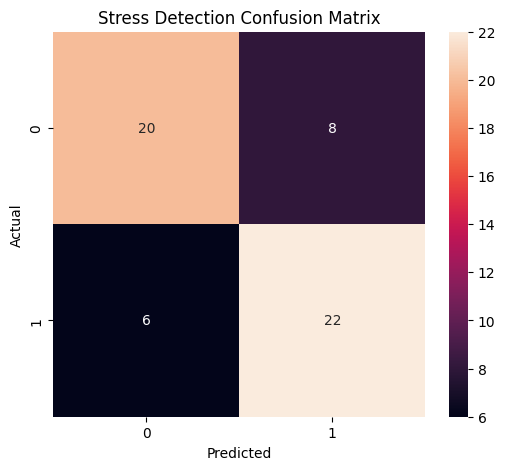

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    labels,
    preds
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Stress Detection Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

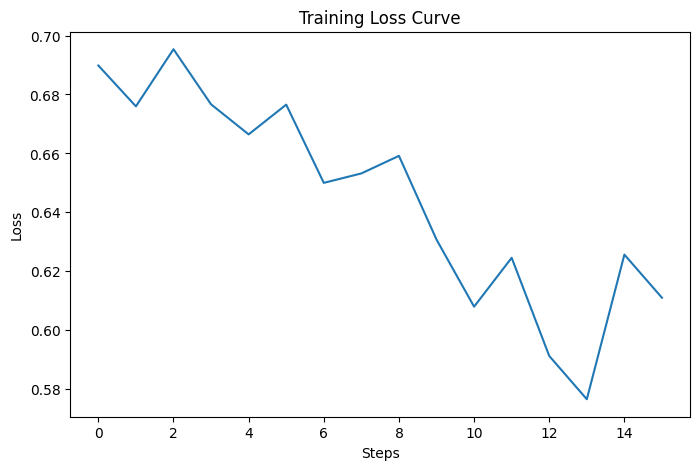

In [40]:
logs = trainer.state.log_history

losses = []

for log in logs:

    if "loss" in log:

        losses.append(
            log["loss"]
        )

plt.figure(figsize=(8,5))

plt.plot(losses)

plt.title(
    "Training Loss Curve"
)

plt.xlabel("Steps")
plt.ylabel("Loss")

plt.show()

In [41]:
model.save_pretrained(
    "stress_model"
)

processor.save_pretrained(
    "stress_model"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['stress_model/processor_config.json']

In [42]:
!zip -r stress_model.zip stress_model

  adding: stress_model/ (stored 0%)
  adding: stress_model/vocab.json (deflated 55%)
  adding: stress_model/processor_config.json (deflated 43%)
  adding: stress_model/config.json (deflated 67%)
  adding: stress_model/checkpoint-56/ (stored 0%)
  adding: stress_model/checkpoint-56/trainer_state.json (deflated 65%)
  adding: stress_model/checkpoint-56/training_args.bin (deflated 53%)
  adding: stress_model/checkpoint-56/config.json (deflated 67%)
  adding: stress_model/checkpoint-56/rng_state.pth (deflated 27%)
  adding: stress_model/checkpoint-56/scheduler.pt (deflated 61%)
  adding: stress_model/checkpoint-56/model.safetensors (deflated 7%)
  adding: stress_model/checkpoint-56/optimizer.pt (deflated 8%)
  adding: stress_model/checkpoint-112/ (stored 0%)
  adding: stress_model/checkpoint-112/trainer_state.json (deflated 70%)
  adding: stress_model/checkpoint-112/training_args.bin (deflated 53%)
  adding: stress_model/checkpoint-112/config.json (deflated 67%)
  adding: stress_model/chec

In [43]:
import torch
import librosa

def predict_audio(path):

    audio, sr = librosa.load(
        path,
        sr=16000
    )

    inputs = processor(
        audio,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    )

    with torch.no_grad():

        logits = model(
            inputs.input_values
        ).logits

    pred = torch.argmax(
        logits,
        dim=1
    ).item()

    return encoder.inverse_transform(
        [pred]
    )[0]

In [45]:
import torch
import librosa

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model.to(device)

def predict_audio(path):

    audio, sr = librosa.load(
        path,
        sr=16000
    )

    inputs = processor(
        audio,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    )

    input_values = inputs.input_values.to(device)

    with torch.no_grad():

        logits = model(
            input_values
        ).logits

    pred = torch.argmax(
        logits,
        dim=1
    ).item()

    return encoder.inverse_transform(
        [pred]
    )[0]

In [46]:
predict_audio(
    "/content/wav_files/audio1.wav"
)

'STRESSED'

In [47]:
results = trainer.evaluate()

print(results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.611012,0.565098,3,0.750000,0.733333,0.785714,0.758621


{'eval_loss': 0.5650983452796936, 'eval_accuracy': 0.75, 'eval_precision': 0.7333333333333333, 'eval_recall': 0.7857142857142857, 'eval_f1': 0.7586206896551724}


In [48]:
predictions = trainer.predict(test_dataset)

preds = np.argmax(
    predictions.predictions,
    axis=1
)

labels = predictions.label_ids

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    labels,
    preds
)

print("Accuracy:", accuracy)

Accuracy: 0.75


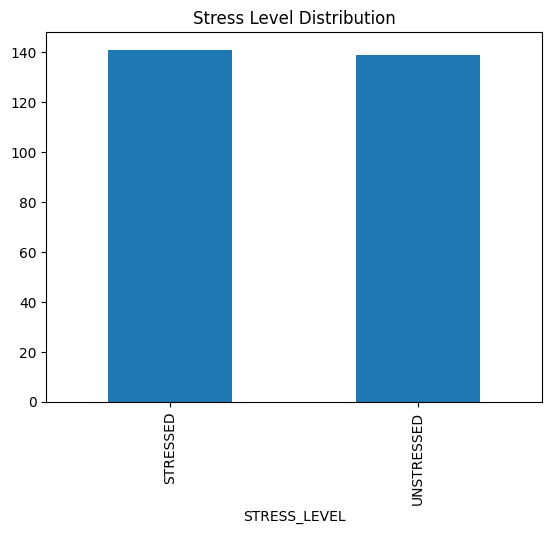

In [49]:
# Class distribution graph
df['STRESS_LEVEL'].value_counts().plot(kind='bar')
plt.title("Stress Level Distribution")
plt.show()

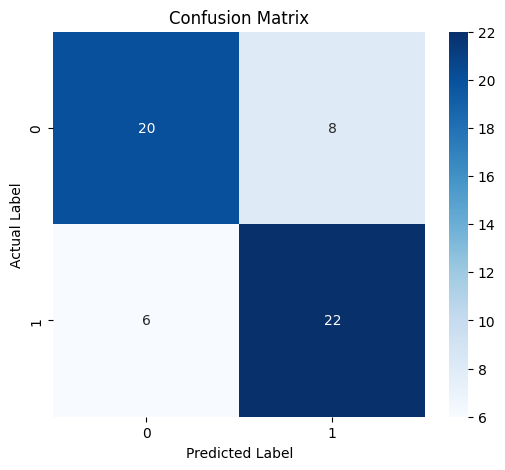

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

predictions = trainer.predict(test_dataset)

preds = np.argmax(
    predictions.predictions,
    axis=1
)

labels = predictions.label_ids

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

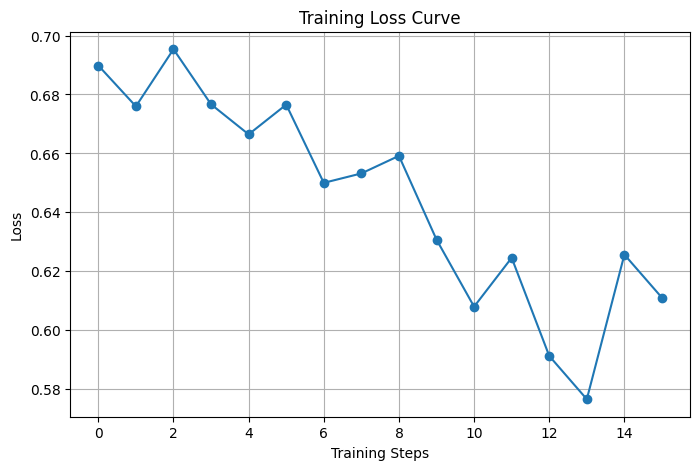

In [51]:
import matplotlib.pyplot as plt

logs = trainer.state.log_history

losses = []

for log in logs:
    if "loss" in log:
        losses.append(log["loss"])

plt.figure(figsize=(8,5))

plt.plot(losses, marker='o')

plt.title("Training Loss Curve")
plt.xlabel("Training Steps")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

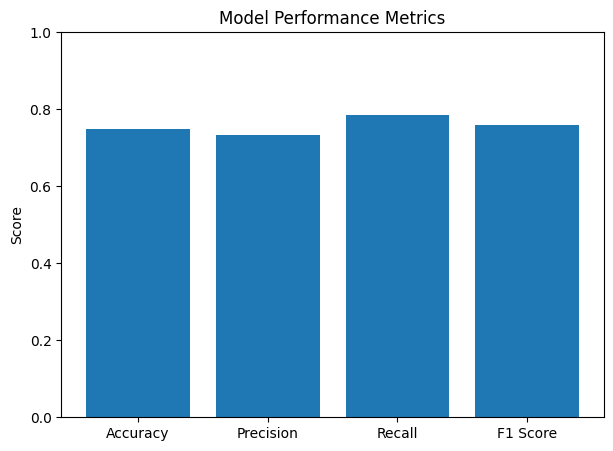

In [52]:
metrics = {
    'Accuracy': 0.75,
    'Precision': 0.7333,
    'Recall': 0.7857,
    'F1 Score': 0.7586
}

plt.figure(figsize=(7,5))

plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.ylim(0,1)

plt.title("Model Performance Metrics")

plt.ylabel("Score")

plt.show()

In [55]:
!ls -lh /content/stress_model.zip

-rw-r--r-- 1 root root 3.3G Jun 17 19:16 /content/stress_model.zip


In [56]:
import os
os.makedirs("final_model", exist_ok=True)

model.save_pretrained("final_model")
processor.save_pretrained("final_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['final_model/processor_config.json']

In [57]:
!zip -r final_model.zip final_model

  adding: final_model/ (stored 0%)
  adding: final_model/vocab.json (deflated 55%)
  adding: final_model/processor_config.json (deflated 43%)
  adding: final_model/config.json (deflated 67%)
  adding: final_model/model.safetensors (deflated 7%)
  adding: final_model/tokenizer_config.json (deflated 73%)


In [58]:
!ls -lh final_model.zip

-rw-r--r-- 1 root root 336M Jun 17 19:47 final_model.zip


In [59]:
from google.colab import files
files.download("final_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>